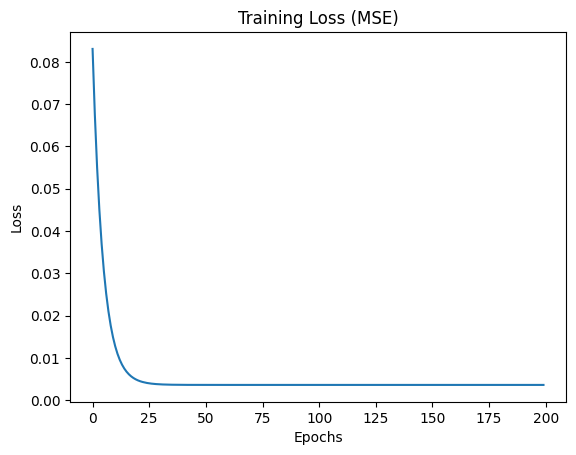

Sample Predictions (Actual vs Predicted):
Actual: 27.27 | Predicted: 26.68
Actual: 70.43 | Predicted: 68.96
Actual: 55.14 | Predicted: 55.96
Actual: 42.11 | Predicted: 41.73
Actual: 30.92 | Predicted: 30.08


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


np.random.seed(42)
X = np.random.rand(100, 2) * 10
y = 3 * X[:, 0] + 5 * X[:, 1] + 10 + np.random.randn(100)
y = y.reshape(-1, 1)

# 2. Preprocessing
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2)

# 3. Linear Perceptron for Regression
class LinearPerceptron:
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.random.randn(X.shape[1], 1)
        self.bias = 0
        self.history = []

        for _ in range(self.epochs):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            # Gradient descent updates
            self.weights -= self.lr * (np.dot(X.T, error) / len(X))
            self.bias -= self.lr * (np.sum(error) / len(X))
            self.history.append(np.mean(error**2))

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# 4. Execution
regressor = LinearPerceptron(lr=0.1, epochs=200)
regressor.fit(X_train, y_train)

# 5. Results
y_pred_scaled = regressor.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test)

plt.plot(regressor.history)
plt.title("Training Loss (MSE)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

print("Sample Predictions (Actual vs Predicted):")
for i in range(5):
    print(f"Actual: {y_actual[i][0]:.2f} | Predicted: {y_pred[i][0]:.2f}")